<a href="https://colab.research.google.com/github/mohsinimam/AIinHealth/blob/main/MohsinImam_MLDL_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **In-Hospital Mortality Prediction (MIMIC-IV)**

## Author: Mohsin Imam
## Note: leveraged Gemini code for coding assistnace

### Step 1: Data Extraction and Preparation
In this step, we will mount Google Drive to access the MIMIC-IV CSV files, load the `admissions` and `patients` tables, merge them, and extract the features necessary for predicting our target variable (`hospital_expire_flag`).

In [19]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

# Define the path to the directory containing your MIMIC-IV CSV files
# Update this path to match where you saved the files in your Google Drive
path_to_mimic = '/'

admissions_path = os.path.join(path_to_mimic, 'admissions.csv')
patients_path = os.path.join(path_to_mimic, 'patients.csv')

# Load the CSV files into Pandas DataFrames
print("Loading admissions.csv...")
df_admissions = pd.read_csv(admissions_path)

print("Loading patients.csv...")
df_patients = pd.read_csv(patients_path)

# Merge the DataFrames on 'subject_id' using an inner join
df_merged = pd.merge(df_admissions, df_patients, on='subject_id', how='inner')

# Keep only the required columns for the binary classification task
columns_to_keep = [
    'subject_id',
    'hadm_id',
    'hospital_expire_flag', # Target: 1 for died, 0 for survived
    'admission_type',
    'admission_location',
    'insurance',
    'gender',
    'anchor_age'
]

df = df_merged[columns_to_keep]

# Print DataFrame info
print("\n--- DataFrame Info ---")
df.info()

# Display the first 5 rows
print("\n--- First 5 Rows ---")
display(df.head())

Loading admissions.csv...
Loading patients.csv...

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            546028 non-null  int64 
 1   hadm_id               546028 non-null  int64 
 2   hospital_expire_flag  546028 non-null  int64 
 3   admission_type        546028 non-null  object
 4   admission_location    546027 non-null  object
 5   insurance             536673 non-null  object
 6   gender                546028 non-null  object
 7   anchor_age            546028 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 33.3+ MB

--- First 5 Rows ---


,subject_id,hadm_id,hospital_expire_flag,admission_type,admission_location,insurance,gender,anchor_age
0,10000032,22595853,0,URGENT,TRANSFER FROM HOSPITAL,Medicaid,F,52
1,10000032,22841357,0,EW EMER.,EMERGENCY ROOM,Medicaid,F,52
2,10000032,25742920,0,EW EMER.,EMERGENCY ROOM,Medicaid,F,52
3,10000032,29079034,0,EW EMER.,EMERGENCY ROOM,Medicaid,F,52
4,10000068,25022803,0,EU OBSERVATION,EMERGENCY ROOM,NaN,F,19


## Step 2: Exploratory Data Analysis (EDA)

Before training a machine learning model, it's crucial to understand our data. We will create a few visualizations to see how different features relate to our target variable (`hospital_expire_flag`).

### 1. Target Variable Distribution
First, let's look at the distribution of our target variable.

**What to look for:** Notice the significant difference in the heights of the bars. In healthcare datasets like MIMIC, mortality is (fortunately) a rare event compared to survival. This creates a **class imbalance**, which is important to keep in mind when evaluating our deep learning model later (accuracy might be misleading, and we may need metrics like AUC-ROC or F1-score).

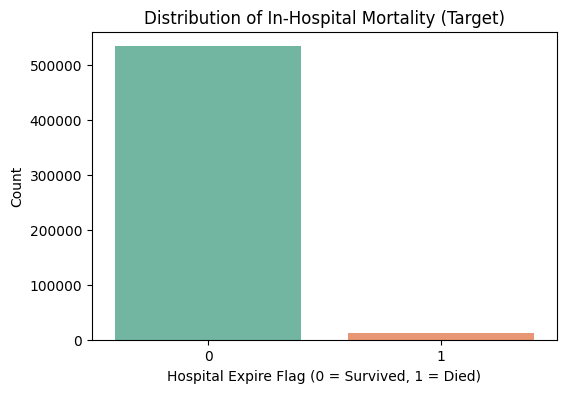

In [20]:
# 1. Distribution of the target variable (hospital_expire_flag)
# Note: This will likely show a severe class imbalance, as most people survive.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='hospital_expire_flag', hue='hospital_expire_flag', palette='Set2', legend=False)
plt.title('Distribution of In-Hospital Mortality (Target)')
plt.xlabel('Hospital Expire Flag (0 = Survived, 1 = Died)')
plt.ylabel('Count')
plt.show()

### 2. Patient Age vs. Mortality
Next, let's examine the relationship between a patient's age and their likelihood of in-hospital mortality.

**What to look for:** Look at the median line (the line inside the box) and the overall spread of the boxplots. Generally, you might expect the 'Died (1)' group to have a higher median age compared to the 'Survived (0)' group, indicating that older patients might have a higher risk of mortality.

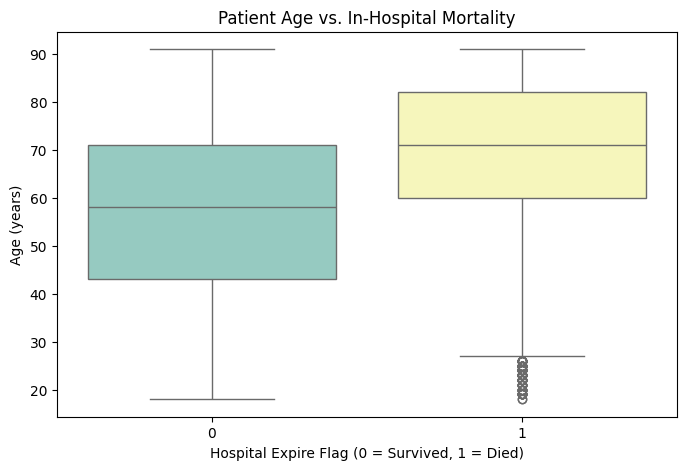

In [21]:
# 2. Patient age vs. Mortality
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='hospital_expire_flag', y='anchor_age', hue='hospital_expire_flag', palette='Set3', legend=False)
plt.title('Patient Age vs. In-Hospital Mortality')
plt.xlabel('Hospital Expire Flag (0 = Survived, 1 = Died)')
plt.ylabel('Age (years)')
plt.show()

### 3. Admission Type vs. Mortality
Finally, let's look at how the type of admission (e.g., Emergency, Urgent, Elective) correlates with mortality.

**What to look for:** Pay attention to the proportions of the orange bars (Died) relative to the blue bars (Survived) within each admission type. You'll likely see that 'EMERGENCY' or 'URGENT' admissions have a higher proportion of mortalities compared to 'ELECTIVE' admissions, which are planned and generally lower risk.

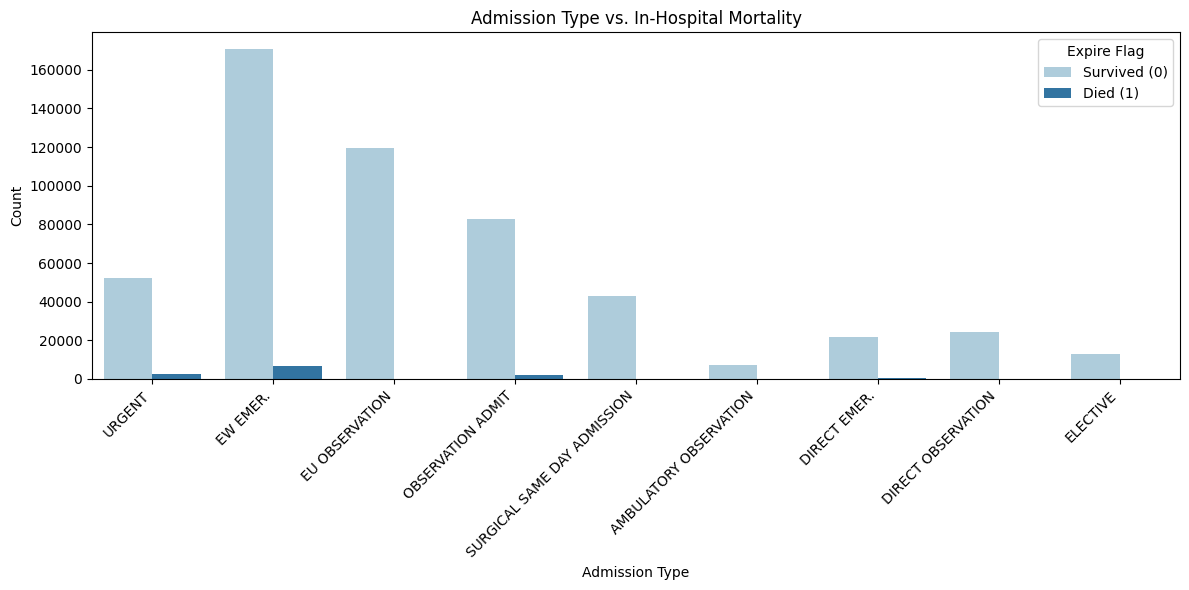

In [22]:
# 3. Admission type separated by Mortality
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='admission_type', hue='hospital_expire_flag', palette='Paired')
plt.title('Admission Type vs. In-Hospital Mortality')
plt.xlabel('Admission Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Expire Flag', labels=['Survived (0)', 'Died (1)'])
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

Before feeding data into a deep learning model, we must prepare it:
1. **Drop identifiers:** `subject_id` and `hadm_id` are unique IDs and don't hold predictive value.
2. **Handle missing values:** We will check for missing values, filling categorical columns with the mode and numerical columns with the median.
3. **Encode categorical variables:** Deep learning models expect numbers. We'll use pandas `get_dummies(drop_first=True)` for one-hot encoding.
4. **Separate features and target:** Split data into `X` and `y`.
5. **Train/Test Split:** We divide our data into an 80% training set and a 20% testing set.
6. **Scale features:** Neural networks learn better when features are scaled. We will initialize a `StandardScaler`, fit it *only* on the training data, and then transform both the train and test sets.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Drop identifiers
df_prep = df.drop(columns=['subject_id', 'hadm_id'])

# 2. Check and handle missing values
categorical_cols = ['admission_type', 'admission_location', 'insurance', 'gender']

# Fill categorical columns with the mode
for col in categorical_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

# Fill numerical columns with the median (anchor_age)
numerical_cols = ['anchor_age']
for col in numerical_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# 3. One-hot encode categorical variables
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

# 4. Separate features (X) and target (y)
X = df_prep.drop(columns=['hospital_expire_flag'])
y = df_prep['hospital_expire_flag']

# 5. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Scale numerical features using StandardScaler
# Initialize StandardScaler, fit ONLY on training data, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame and cast to float32 (standard for deep learning)
X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index).astype('float32')
X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index).astype('float32')

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
display(X_train.head())

Training data shape: (436822, 24)
Testing data shape: (109206, 24)


,anchor_age,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,...,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,gender_M
100489,-0.521063,-0.204429,-0.216939,-0.155839,-0.529690,-0.693961,2.336552,-0.291335,-0.334802,-0.156515,...,1.532959,-0.125882,-0.338632,-0.108418,-0.290617,-0.931527,-0.028318,-0.162907,-0.682349,1.041375
358683,-1.206200,-0.204429,-0.216939,-0.155839,1.887898,-0.693961,-0.427981,-0.291335,-0.334802,-0.156515,...,-0.652333,-0.125882,-0.338632,-0.108418,-0.290617,-0.931527,-0.028318,-0.162907,-0.682349,1.041375
86695,0.849212,4.891676,-0.216939,-0.155839,-0.529690,-0.693961,-0.427981,-0.291335,-0.334802,6.389144,...,-0.652333,-0.125882,-0.338632,-0.108418,-0.290617,1.073506,-0.028318,-0.162907,-0.682349,-0.960269
268739,0.480292,-0.204429,-0.216939,-0.155839,-0.529690,-0.693961,2.336552,-0.291335,-0.334802,6.389144,...,-0.652333,-0.125882,-0.338632,-0.108418,-0.290617,1.073506,-0.028318,-0.162907,-0.682349,-0.960269
264993,1.060023,-0.204429,-0.216939,-0.155839,-0.529690,-0.693961,2.336552,-0.291335,-0.334802,-0.156515,...,1.532959,-0.125882,-0.338632,-0.108418,-0.290617,1.073506,-0.028318,-0.162907,-0.682349,-0.960269


## Step 4: Baseline Model (Logistic Regression)

Before jumping into Deep Learning, we need a baseline to compare it against. Logistic Regression is a highly interpretable standard in healthcare, making it the perfect baseline. We will evaluate it using a classification report and a confusion matrix.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    106962
           1       0.00      0.00      0.00      2244

    accuracy                           0.98    109206
   macro avg       0.49      0.50      0.49    109206
weighted avg       0.96      0.98      0.97    109206



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


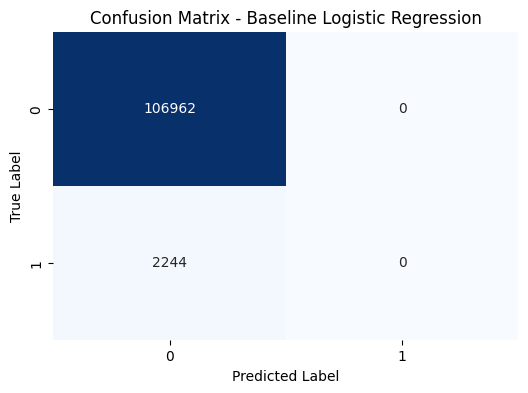

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model
# Logistic Regression is a highly interpretable standard in healthcare, making it the perfect baseline.
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = log_reg.predict(X_test)

# Evaluate the model
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Step 5: Building and Training the Deep Learning Model

Now that we have a baseline, we will use TensorFlow and Keras to build an Artificial Neural Network (ANN) for our binary classification task. We will construct a Sequential Multi-Layer Perceptron (MLP) and train it using our preprocessed data.

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# Get the number of input features
input_dim = X_train.shape[1]

# Initialize the Sequential model
model = Sequential([
    # Input layer that matches the number of features
    Input(shape=(input_dim,)),

    # First hidden Dense layer
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Second hidden Dense layer
    Dense(32, activation='relu'),
    Dropout(0.3),

    # Output Dense layer (1 neuron, sigmoid for binary classification)
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Print the model summary
model.summary()

# Train the model
print("\n--- Training the Model ---")
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)


--- Training the Model ---
Epoch 1/20
3413/3413 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9778 - auc: 0.7654 - loss: 0.0982 - val_accuracy: 0.9799 - val_auc: 0.8112 - val_loss: 0.0852
Epoch 2/20
3413/3413 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9785 - auc: 0.7946 - loss: 0.0913 - val_accuracy: 0.9799 - val_auc: 0.8124 - val_loss: 0.0850
Epoch 3/20
3413/3413 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9786 - auc: 0.8019 - loss: 0.0902 - val_accuracy: 0.9799 - val_auc: 0.8133 - val_loss: 0.0848
Epoch 4/20
3413/3413 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9786 - auc: 0.8057 - loss: 0.0898 - val_accuracy: 0.9799 - val_auc: 0.8133 - val_loss: 0.0848
Epoch 5/20
3413/3413 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9786 - auc: 0.8082 - loss: 0.0894 - val_accuracy: 0.9799 - val_auc: 0.8128 - val_loss: 0.0848
Epoch 6/20
3413/3413 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9786 - auc: 0.8101 - loss: 0.0891 - val_accuracy: 0.9799 - val_auc: 0.8130 - val_loss: 0.0847


## Step 6: Model Evaluation and Comparison

Finally, we evaluate our trained Neural Network and compare its performance against the Logistic Regression baseline.

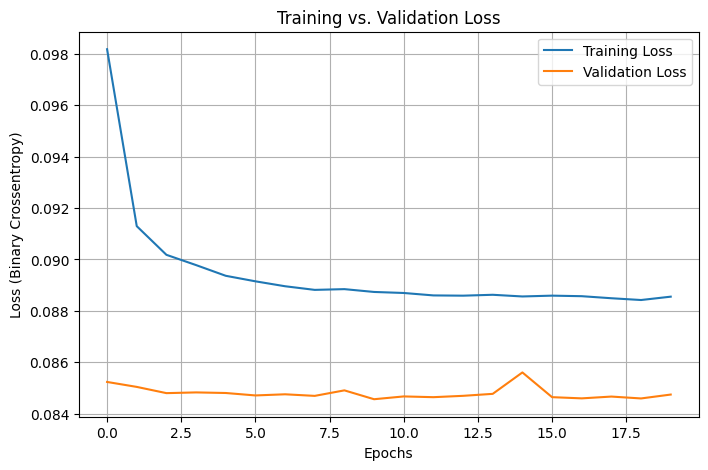

In [26]:
import matplotlib.pyplot as plt

# Plot the training loss vs. validation loss over the 20 epochs
# This is a great chart to show if the model overfit
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

3413/3413 ━━━━━━━━━━━━━━━━━━━━ 3s 828us/step
--- Deep Learning Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    106962
           1       0.80      0.03      0.06      2244

    accuracy                           0.98    109206
   macro avg       0.89      0.51      0.52    109206
weighted avg       0.98      0.98      0.97    109206



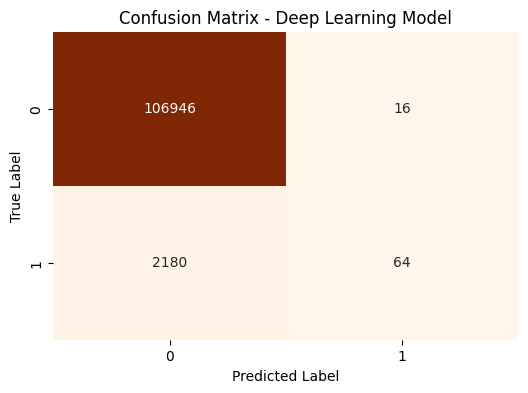

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Generate model predictions on X_test (outputs are probabilities)
y_pred_probs = model.predict(X_test)

# Convert output probabilities to binary classes (0 or 1) using a 0.5 threshold
y_pred_nn = (y_pred_probs >= 0.5).astype(int)

# Print the classification_report
print("--- Deep Learning Classification Report ---")
print(classification_report(y_test, y_pred_nn))

# Plot the Confusion Matrix for the Neural Network
plt.figure(figsize=(6, 4))
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix - Deep Learning Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

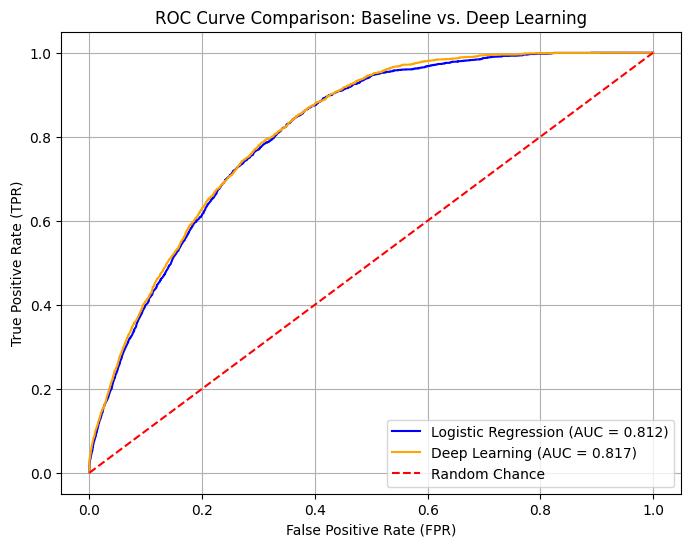

In [28]:
from sklearn.metrics import roc_curve, auc

# Calculate probabilities for Logistic Regression
y_pred_probs_log = log_reg.predict_proba(X_test)[:, 1]

# Calculate FPR, TPR, and AUC for Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_probs_log)
auc_log = auc(fpr_log, tpr_log)

# Calculate FPR, TPR, and AUC for Deep Learning
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_probs)
auc_nn = auc(fpr_nn, tpr_nn)

# Create an ROC Curve plot to visually compare both models
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', color='blue')
plt.plot(fpr_nn, tpr_nn, label=f'Deep Learning (AUC = {auc_nn:.3f})', color='orange')

# Add a diagonal dashed line for random chance
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Chance')

plt.title('ROC Curve Comparison: Baseline vs. Deep Learning')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()